# 2. Kiểm định giả thuyết

Kiểm định các giả thuyết nghiên cứu trên tập dữ liệu **Heart Disease Dataset**.

Với mỗi giả thuyết, ta đặt ra hai mệnh đề đối lập:
- **H₀ (giả thuyết không):** mệnh đề "không có khác biệt / không có liên hệ" — được xem là đúng cho tới khi dữ liệu chứng minh ngược lại.
- **H₁ (giả thuyết nghiên cứu):** điều ta muốn chứng minh.

Nếu **p-value < α** thì dữ liệu đủ mạnh để **bác bỏ H₀** ở mức ý nghĩa α; ngược lại thì **chưa đủ bằng chứng để bác bỏ H₀**. Lưu ý: kiểm định tần suất không bao giờ "chấp nhận" một giả thuyết — bác bỏ H₀ chỉ có nghĩa dữ liệu không tương thích với H₀, chứ không chứng minh H₁ là đúng.

**Mức ý nghĩa:** α = 0,05 cho tất cả kiểm định.

## Các giả thuyết nghiên cứu

| Mã | Câu hỏi đặt ra | H₀ (không khác biệt) | H₁ (điều muốn chứng minh) |
|----|----------------|----------------------|----------------------------|
| **GT1** | Người có bệnh tim có nhịp tim tối đa cao hơn người không bệnh không? | Nhịp tim tối đa trung bình của nhóm có bệnh **không cao hơn** nhóm không bệnh | Nhịp tim tối đa (`thalach`) của nhóm **có bệnh cao hơn** nhóm không bệnh |
| **GT2** | Tỉ lệ mắc bệnh tim ở nam và nữ có khác nhau không? | Tỉ lệ mắc bệnh tim ở nữ **bằng** ở nam | Tỉ lệ mắc bệnh tim ở nam và nữ (`sex`) **khác nhau** |
| **GT3** | Loại đau ngực có liên quan đến việc mắc bệnh tim không? | Loại đau ngực (`cp`) **không liên quan** đến việc mắc bệnh tim | Loại đau ngực (`cp`) **có liên quan** đến việc mắc bệnh tim |

In [1]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


## 2.1. Phương pháp kiểm định

| Mã | H₀ | H₁ (nghiên cứu) | Phương pháp | Điều kiện áp dụng | α |
|----|----|-----------------|-------------|-------------------|---|
| **GT1** | μ_thalach(bệnh) ≤ μ_thalach(không bệnh) | μ_thalach(bệnh) > μ_thalach(không bệnh) | **Welch t-test** hai mẫu độc lập (một phía); dự phòng **Wilcoxon rank-sum** | Hai nhóm độc lập theo `target`; không giả định phương sai đồng nhất | 0,05 (một phía) |
| **GT2** | p(bệnh\|nữ) = p(bệnh\|nam) | p(bệnh\|nữ) ≠ p(bệnh\|nam) | **Z hai tỉ lệ** (hai phía); kiểm chứng **χ² độc lập** (bảng 2×2) | Mẫu lớn, np và n(1−p) ≥ 5 | 0,05 (hai phía) |
| **GT3** | `cp` ⊥ `target` (độc lập) | `cp` và `target` có liên hệ | **χ² kiểm định độc lập** (bảng 4×2) | Tần số kỳ vọng mỗi ô ≥ 5 | 0,05 (đuôi trên) |

> **Ghi chú kỹ thuật:** với các kiểm định χ² độc lập (đuôi trên), quy tắc bác bỏ là **χ² > χ²₍α; df₎** (tương đương **p-value < α**). Notebook quyết định trực tiếp theo p-value để tránh phụ thuộc trường `reject_h0` của engine (vốn gắn nhãn hai phía cho họ χ²).

In [2]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

import hypothesis_testing
importlib.reload(hypothesis_testing)
from hypothesis_testing import hypothesis_test

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

ALPHA = 0.05
DATA_PATH = Path("dataset/heart.csv")
df = pd.read_csv(DATA_PATH)

## 2.2. Kiểm định GT1 — Welch t-test hai mẫu độc lập (một phía)

**Câu hỏi:** Người có bệnh tim có nhịp tim tối đa cao hơn người không bệnh không?

**Giả thuyết không (H₀):** Nhịp tim tối đa trung bình của nhóm có bệnh **không cao hơn** nhóm không bệnh (bằng hoặc thấp hơn).

→ $\mu_{\text{thalach}}(\text{bệnh}) - \mu_{\text{thalach}}(\text{không bệnh}) \leq 0$

**Giả thuyết nghiên cứu (H₁):** Nhịp tim tối đa trung bình của nhóm **có bệnh cao hơn** nhóm không bệnh.

→ $\mu_{\text{thalach}}(\text{bệnh}) - \mu_{\text{thalach}}(\text{không bệnh}) > 0$

**Phương pháp:** Welch t-test hai mẫu độc lập (một phía, **không giả định phương sai bằng nhau**); dự phòng Wilcoxon rank-sum.

**Bác bỏ H₀ khi:** p-value < α. **Mức ý nghĩa:** α = 0,05.

=== Thống kê mô tả nhịp tim tối đa (thalach) theo tình trạng bệnh ===


,Số mẫu,Trung bình,Trung vị,Độ lệch chuẩn,Phương sai
Nhóm,,,,,
Có bệnh (1),526,158.585551,161.5,19.096928,364.692667
Không bệnh (0),499,139.130261,142.0,22.565235,509.189825


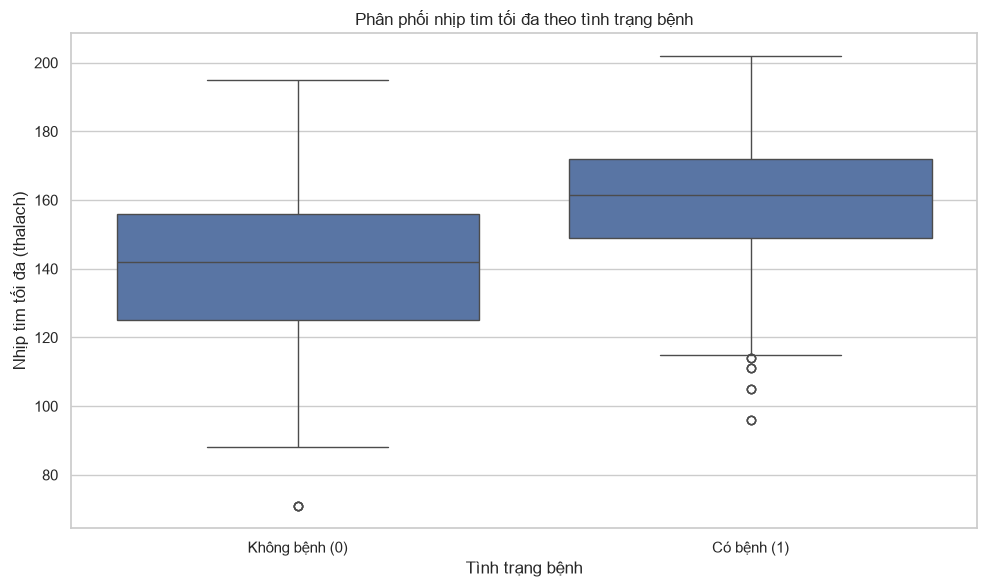

In [3]:
# Thống kê mô tả thalach theo tình trạng bệnh
grp_label = {0: "Không bệnh (0)", 1: "Có bệnh (1)"}
df_g1 = df.assign(**{"Nhóm": df["target"].map(grp_label)})

thalach_by_target = (
    df_g1.groupby("Nhóm")["thalach"]
    .agg(["count", "mean", "median", "std", "var"])
    .rename(columns={"count": "Số mẫu", "mean": "Trung bình", "median": "Trung vị",
                     "std": "Độ lệch chuẩn", "var": "Phương sai"})
)
print("=== Thống kê mô tả nhịp tim tối đa (thalach) theo tình trạng bệnh ===")
display(thalach_by_target)

fig, ax = plt.subplots()
sns.boxplot(data=df_g1, x="Nhóm", y="thalach", order=["Không bệnh (0)", "Có bệnh (1)"], ax=ax)
ax.set_xlabel("Tình trạng bệnh")
ax.set_ylabel("Nhịp tim tối đa (thalach)")
ax.set_title("Phân phối nhịp tim tối đa theo tình trạng bệnh")
plt.tight_layout()
plt.show()

In [4]:
benh = df.loc[df["target"] == 1, "thalach"]
khong_benh = df.loc[df["target"] == 0, "thalach"]

s1 = benh.std(ddof=1)
s2 = khong_benh.std(ddof=1)
print("=== Phương sai hai nhóm (Welch không giả định σ₁ = σ₂) ===")
print(f"Có bệnh:   s² = {s1**2:.4f},  s = {s1:.4f},  n = {len(benh)}")
print(f"Không bệnh: s² = {s2**2:.4f},  s = {s2:.4f},  n = {len(khong_benh)}")
# --- Kiểm tra giả định trước khi chọn kiểm định ---
print("\n=== Kiểm tra giả định GT1 ===")

# (a) Tính chuẩn của từng nhóm (Shapiro-Wilk)
sw1 = stats.shapiro(benh)
sw2 = stats.shapiro(khong_benh)
print(f"Shapiro-Wilk nhóm có bệnh:    W = {sw1.statistic:.4f}, p = {sw1.pvalue:.4e}")
print(f"Shapiro-Wilk nhóm không bệnh: W = {sw2.statistic:.4f}, p = {sw2.pvalue:.4e}")
print("→ Cả hai nhóm đều bác bỏ giả thuyết phân phối chuẩn ở α = 0,05.")
print(f"   Tuy nhiên n₁ = {len(benh)} và n₂ = {len(khong_benh)} đều lớn, nên theo định lý")
print("   giới hạn trung tâm, phân phối của trung bình mẫu vẫn xấp xỉ chuẩn.")
print("   Kiểm định t hai mẫu do đó vẫn dùng được.")

# (b) Bằng nhau của hai phương sai — căn cứ chọn Welch thay vì t gộp
res_f = hypothesis_test(
    "f_two_variances",
    s1_2=s2**2, s2_2=s1**2, n1=len(khong_benh), n2=len(benh),
    alpha=ALPHA, alternative="two-sided",
)
print(f"\nKiểm định F hai phương sai: F = {res_f['statistic']:.4f}, "
      f"df = ({res_f['df1']}, {res_f['df2']}), p = {res_f['p_value']:.4e}")
print("→ Bác bỏ giả thuyết hai phương sai bằng nhau, nên dùng Welch")
print("   (không gộp phương sai) là lựa chọn đúng.")

H0 = "Nhịp tim tối đa trung bình ở nhóm có bệnh không cao hơn nhóm không bệnh."
H1 = "Nhịp tim tối đa trung bình ở nhóm có bệnh cao hơn nhóm không bệnh."

# Welch t-test một phía: bệnh > không bệnh
res_t = hypothesis_test(
    "t_two_means_welch",
    x1=benh.mean(), x2=khong_benh.mean(), s1=s1, s2=s2,
    n1=len(benh), n2=len(khong_benh),
    alpha=ALPHA, alternative="greater",
)
print("\n=== Kiểm định Welch t hai mẫu độc lập: GT1 ===")
print(f"Thống kê {res_t['statistic_name']} = {res_t['statistic']:.4f}")
print(f"Bậc tự do Welch df = {res_t['df']:.2f}")
print(f"Giá trị tới hạn = {res_t['critical_value']:.4f}")
print(f"p-value = {res_t['p_value']:.6e}")
print(f"Mức ý nghĩa α = {ALPHA}")
reject_t = res_t["p_value"] < ALPHA
print(f"\nBác bỏ H₀ ? → {reject_t}")
# --- Cỡ hiệu ứng và khoảng tin cậy ---
# p-value phản ánh đồng thời cỡ hiệu ứng và cỡ mẫu, nên tự nó không đo được
# độ mạnh của khác biệt. Báo cáo kèm cỡ hiệu ứng và KTC mới đủ diễn giải.
diff_means = benh.mean() - khong_benh.mean()
se_diff = np.sqrt(s1**2 / len(benh) + s2**2 / len(khong_benh))
t_ci = stats.t.ppf(0.975, res_t["df"])
ci_low, ci_high = diff_means - t_ci * se_diff, diff_means + t_ci * se_diff
s_pooled = np.sqrt(((len(benh) - 1) * s1**2 + (len(khong_benh) - 1) * s2**2)
                   / (len(benh) + len(khong_benh) - 2))
cohen_d = diff_means / s_pooled
print(f"\nChênh lệch trung bình = {diff_means:.4f} nhịp/phút")
print(f"KTC 95% cho chênh lệch = ({ci_low:.4f}; {ci_high:.4f})")
print(f"Cohen's d = {cohen_d:.4f}  (|d| ≈ 0,8 trở lên: hiệu ứng lớn)")

# Dự phòng phi tham số: Wilcoxon rank-sum (một phía)
res_w = hypothesis_test(
    "wilcoxon_rank_sum",
    sample1=benh.values, sample2=khong_benh.values,
    alpha=ALPHA, alternative="greater",
)
print("\n=== Kiểm định Wilcoxon rank-sum (dự phòng) ===")
if res_w["use_z_approx"]:
    print(f"Phương pháp: mẫu lớn (n1={res_w['n1']}, n2={res_w['n2']} > 10) → xấp xỉ Z")
    print(f"Thống kê U = {res_w['statistic']:.4f}")
    print(f"μ_U = {res_w['mu_u']:.4f},  σ_U = {res_w['sigma_u']:.4f}")
    print(f"Z = (U - μ_U) / σ_U = {res_w['z']:.4f}")
    print(f"Z > Z_α ?  {res_w['z']:.4f} > {res_w['critical_value']:.4f} → {res_w['z'] > res_w['critical_value']}")
print(f"p-value = {res_w['p_value']:.6e}")
print(f"Bác bỏ H₀ ? → {res_w['reject_h0']}")
# --- Giả định hình dạng của Wilcoxon rank-sum ---
# Wilcoxon KHÔNG phải "phi giả định": nó kiểm định P(X₁ > X₀) + ½·P(X₁ = X₀) = 1/2,
# và chỉ tương đương kiểm định trung vị khi hai phân phối cùng hình dạng. Kiểm:
iqr1 = benh.quantile(0.75) - benh.quantile(0.25)
iqr0 = khong_benh.quantile(0.75) - khong_benh.quantile(0.25)
shifted = benh - (benh.median() - khong_benh.median())
ks = stats.ks_2samp(shifted, khong_benh)
p_sup = res_w["statistic"] / (len(benh) * len(khong_benh))
print(f"\nIQR nhóm có bệnh = {iqr1:.1f} so với nhóm không bệnh = {iqr0:.1f}")
print(f"KS sau khi tịnh tiến cho trùng trung vị: p = {ks.pvalue:.4e}")
print("→ Hai phân phối KHÔNG cùng hình dạng, nên kết quả Wilcoxon phải hiểu là")
print("   kiểm định về ưu thế ngẫu nhiên, không phải về trung vị.")
# U/(n₁n₀) là đại lượng CÓ hiệu chỉnh đồng hạng, không phải P(X₁ > X₀) thuần tuý.
# Ở đây hai đại lượng lệch nhau thấy rõ vì thalach có nhiều giá trị trùng.
p_gt = (benh.values[:, None] > khong_benh.values[None, :]).mean()
p_eq = (benh.values[:, None] == khong_benh.values[None, :]).mean()
print(f"Ưu thế ngẫu nhiên U/(n₁n₀) = P(X₁ > X₀) + ½·P(X₁ = X₀) = {p_sup:.4f}")
print(f"   trong đó P(X₁ > X₀) = {p_gt:.4f} và P(X₁ = X₀) = {p_eq:.4f}")

print("\n" + "-" * 50)
if reject_t:
    print("Kết luận: Bác bỏ H₀ ở mức ý nghĩa α = 0,05.")
    print(f"→ {H1}")
else:
    print("Kết luận: Không bác bỏ H₀.")
    print(f"→ {H0}")

=== Phương sai hai nhóm (Welch không giả định σ₁ = σ₂) ===
Có bệnh:   s² = 364.6927,  s = 19.0969,  n = 526
Không bệnh: s² = 509.1898,  s = 22.5652,  n = 499

=== Kiểm tra giả định GT1 ===
Shapiro-Wilk nhóm có bệnh:    W = 0.9677, p = 2.3469e-09
Shapiro-Wilk nhóm không bệnh: W = 0.9878, p = 3.6253e-04
→ Cả hai nhóm đều bác bỏ giả thuyết phân phối chuẩn ở α = 0,05.
   Tuy nhiên n₁ = 526 và n₂ = 499 đều lớn, nên theo định lý
   giới hạn trung tâm, phân phối của trung bình mẫu vẫn xấp xỉ chuẩn.
   Kiểm định t hai mẫu do đó vẫn dùng được.

Kiểm định F hai phương sai: F = 1.3962, df = (498, 525), p = 1.6409e-04
→ Bác bỏ giả thuyết hai phương sai bằng nhau, nên dùng Welch
   (không gộp phương sai) là lựa chọn đúng.

=== Kiểm định Welch t hai mẫu độc lập: GT1 ===
Thống kê T = 14.8615
Bậc tự do Welch df = 976.86
Giá trị tới hạn = 1.6464
p-value = 1.709433e-45
Mức ý nghĩa α = 0.05

Bác bỏ H₀ ? → True

Chênh lệch trung bình = 19.4553 nhịp/phút
KTC 95% cho chênh lệch = (16.8863; 22.0243)
Cohen's 

## 2.3. Kiểm định GT2 — Z kiểm định khác biệt hai tỉ lệ (hai phía)

**Câu hỏi:** Tỉ lệ mắc bệnh tim ở nam và nữ có khác nhau không?

**Giả thuyết không (H₀):** Tỉ lệ mắc bệnh tim ở nữ **bằng** ở nam.

→ $p(\text{bệnh}\,|\,\text{nữ}) = p(\text{bệnh}\,|\,\text{nam})$

**Giả thuyết nghiên cứu (H₁):** Tỉ lệ mắc bệnh tim ở nam và nữ **khác nhau**.

→ $p(\text{bệnh}\,|\,\text{nữ}) \neq p(\text{bệnh}\,|\,\text{nam})$

**Phương pháp:** Z hai tỉ lệ (hai phía); kiểm chứng bằng χ² kiểm định độc lập (bảng 2×2).

**Quy ước mã hóa:** `sex` = 0 → nữ, `sex` = 1 → nam. Tỉ lệ mắc bệnh = P(`target` = 1).

**Bác bỏ H₀ khi:** p-value < α. **Mức ý nghĩa:** α = 0,05.

=== Bảng chéo giới tính × tình trạng bệnh ===


,Không bệnh (0),Có bệnh (1),Tổng,Tỉ lệ bệnh (%)
sex,,,,
Nam,413,300,713,42.08
Nữ,86,226,312,72.44


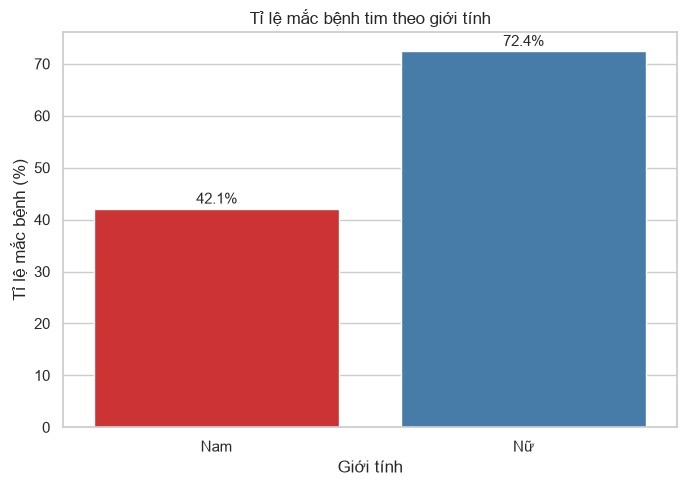

In [5]:
# Bảng chéo giới tính × tình trạng bệnh
sex_label = {0: "Nữ", 1: "Nam"}
ct_sex = pd.crosstab(df["sex"].map(sex_label), df["target"])
ct_sex.columns = ["Không bệnh (0)", "Có bệnh (1)"]
ct_sex["Tổng"] = ct_sex.sum(axis=1)
ct_sex["Tỉ lệ bệnh (%)"] = (ct_sex["Có bệnh (1)"] / ct_sex["Tổng"] * 100).round(2)
print("=== Bảng chéo giới tính × tình trạng bệnh ===")
display(ct_sex)

fig, ax = plt.subplots(figsize=(7, 5))
ty_le = ct_sex["Tỉ lệ bệnh (%)"]
sns.barplot(x=ty_le.index, y=ty_le.values, hue=ty_le.index, palette="Set1", legend=False, ax=ax)
ax.set_xlabel("Giới tính")
ax.set_ylabel("Tỉ lệ mắc bệnh (%)")
ax.set_title("Tỉ lệ mắc bệnh tim theo giới tính")
for i, v in enumerate(ty_le.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

In [6]:
# Nhóm 1 = nữ (sex=0), Nhóm 2 = nam (sex=1)
nu = df[df["sex"] == 0]
nam = df[df["sex"] == 1]
f1 = int((nu["target"] == 1).sum()); n1 = len(nu)
f2 = int((nam["target"] == 1).sum()); n2 = len(nam)

H0 = "Tỉ lệ mắc bệnh tim ở nữ bằng ở nam."
H1 = "Tỉ lệ mắc bệnh tim ở nam và nữ khác nhau."

res_z = hypothesis_test(
    "z_two_proportions",
    f1=f1, n1=n1, f2=f2, n2=n2,
    alpha=ALPHA, alternative="two-sided",
)
print("=== Kiểm định Z hai tỉ lệ: GT2 ===")
print(f"Tỉ lệ bệnh ở nữ  (p̂₁) = {res_z['p1']:.4f}  ({f1}/{n1})")
print(f"Tỉ lệ bệnh ở nam (p̂₂) = {res_z['p2']:.4f}  ({f2}/{n2})")
print(f"Tỉ lệ gộp p̄ = {res_z['p_bar']:.4f}")
print(f"Thống kê {res_z['statistic_name']} = {res_z['statistic']:.4f}")
low, high = res_z['critical_value']
print(f"Giá trị tới hạn ±Z_(α/2) = ({low:.4f}, {high:.4f})")
print(f"p-value = {res_z['p_value']:.6e}")
print(f"Mức ý nghĩa α = {ALPHA}")
reject_z = res_z["reject_h0"]
print(f"|Z| > Z_(α/2) ?  {abs(res_z['statistic']):.4f} > {high:.4f} → {reject_z}")
# --- Điều kiện xấp xỉ chuẩn và cỡ hiệu ứng ---
p_bar = res_z["p_bar"]
print("\n=== Kiểm tra điều kiện GT2 ===")
print(f"n₁·p̄ = {n1 * p_bar:.1f},  n₁(1−p̄) = {n1 * (1 - p_bar):.1f}")
print(f"n₂·p̄ = {n2 * p_bar:.1f},  n₂(1−p̄) = {n2 * (1 - p_bar):.1f}")
print("→ Cả bốn đại lượng đều ≥ 5, xấp xỉ chuẩn dùng được.")

p1, p2 = res_z["p1"], res_z["p2"]
d_prop = p1 - p2
se_prop = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
z95 = stats.norm.ppf(0.975)
print(f"\nChênh lệch tỉ lệ = {d_prop:.4f}")
print(f"KTC 95% cho chênh lệch tỉ lệ = ({d_prop - z95 * se_prop:.4f}; "
      f"{d_prop + z95 * se_prop:.4f})")

# Kiểm chứng bằng χ² độc lập (bảng 2×2)
ct = pd.crosstab(df["sex"], df["target"]).values
res_c = hypothesis_test("chi2_independence", observed=ct, alpha=ALPHA)
reject_c = res_c["p_value"] < ALPHA
print("\n=== Kiểm chứng χ² độc lập (bảng 2×2) ===")
print(f"Thống kê χ² = {res_c['statistic']:.4f}  (df = {res_c['df']})")
print(f"Giá trị tới hạn χ²_(α; df) = {res_c['critical_value']:.4f}")
print(f"p-value = {res_c['p_value']:.6e}")
print(f"χ² > χ²_tới hạn ?  {res_c['statistic']:.4f} > {res_c['critical_value']:.4f} → {res_c['statistic'] > res_c['critical_value']}")
# Lưu ý: Z² ≈ χ² với bảng 2×2
print(f"Kiểm tra quan hệ Z² ≈ χ²:  Z² = {res_z['statistic']**2:.4f} ≈ χ² = {res_c['statistic']:.4f}")

print("\n" + "-" * 50)
if reject_z:
    print("Kết luận: Bác bỏ H₀ ở mức ý nghĩa α = 0,05.")
    print(f"→ {H1}")
else:
    print("Kết luận: Không bác bỏ H₀.")
    print(f"→ {H0}")

=== Kiểm định Z hai tỉ lệ: GT2 ===
Tỉ lệ bệnh ở nữ  (p̂₁) = 0.7244  (226/312)
Tỉ lệ bệnh ở nam (p̂₂) = 0.4208  (300/713)
Tỉ lệ gộp p̄ = 0.5132
Thống kê Z = 8.9484
Giá trị tới hạn ±Z_(α/2) = (-1.9600, 1.9600)
p-value = 3.607035e-19
Mức ý nghĩa α = 0.05
|Z| > Z_(α/2) ?  8.9484 > 1.9600 → True

=== Kiểm tra điều kiện GT2 ===
n₁·p̄ = 160.1,  n₁(1−p̄) = 151.9
n₂·p̄ = 365.9,  n₂(1−p̄) = 347.1
→ Cả bốn đại lượng đều ≥ 5, xấp xỉ chuẩn dùng được.

Chênh lệch tỉ lệ = 0.3036
KTC 95% cho chênh lệch tỉ lệ = (0.2422; 0.3650)

=== Kiểm chứng χ² độc lập (bảng 2×2) ===
Thống kê χ² = 78.8631  (df = 1)
Giá trị tới hạn χ²_(α; df) = 3.8415
p-value = 6.656821e-19
χ² > χ²_tới hạn ?  78.8631 > 3.8415 → True
Kiểm tra quan hệ Z² ≈ χ²:  Z² = 80.0737 ≈ χ² = 78.8631

--------------------------------------------------
Kết luận: Bác bỏ H₀ ở mức ý nghĩa α = 0,05.
→ Tỉ lệ mắc bệnh tim ở nam và nữ khác nhau.


## 2.4. Kiểm định GT3 — χ² kiểm định sự độc lập (bảng 4×2)

**Câu hỏi:** Loại đau ngực có liên quan đến việc mắc bệnh tim không?

**Giả thuyết không (H₀):** Loại đau ngực (`cp`) và việc mắc bệnh tim (`target`) **không liên quan** với nhau (độc lập).

**Giả thuyết nghiên cứu (H₁):** Loại đau ngực (`cp`) **có liên quan** đến việc mắc bệnh tim.

**Phương pháp:** χ² kiểm định độc lập giữa hai biến định tính, bảng tiếp liên 4×2 (cp có 4 mức: 0, 1, 2, 3).

**Trị thống kê:** $\chi^2 = \sum \dfrac{(O_{ij} - E_{ij})^2}{E_{ij}}$, bậc tự do $(r-1)(c-1)$.

**Bác bỏ H₀ khi:** $\chi^2 > \chi^2_{\alpha;\,(r-1)(c-1)}$ (tương đương p-value < α). **Mức ý nghĩa:** α = 0,05.

=== Bảng tiếp liên: loại đau ngực × tình trạng bệnh ===


,Không bệnh (0),Có bệnh (1)
cp,,
cp=0 điển hình,375,122
cp=1 không điển hình,33,134
cp=2 không do đau thắt,65,219
cp=3 không triệu chứng,26,51


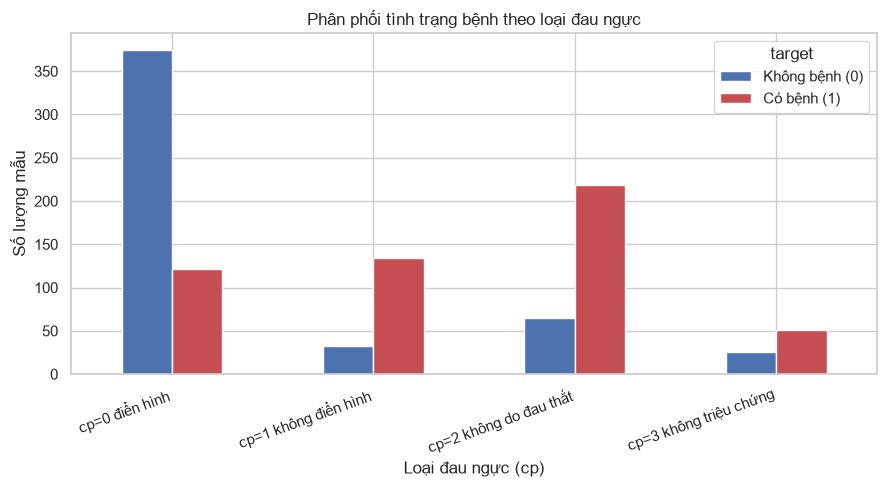

In [7]:
# Bảng tiếp liên cp × target
cp_label = {0: "cp=0 điển hình", 1: "cp=1 không điển hình",
            2: "cp=2 không do đau thắt", 3: "cp=3 không triệu chứng"}
ct_cp = pd.crosstab(df["cp"].map(cp_label), df["target"])
ct_cp.columns = ["Không bệnh (0)", "Có bệnh (1)"]
print("=== Bảng tiếp liên: loại đau ngực × tình trạng bệnh ===")
display(ct_cp)

ax = ct_cp.plot(kind="bar", figsize=(9, 5), color=["#4C72B0", "#C44E52"])
ax.set_xlabel("Loại đau ngực (cp)")
ax.set_ylabel("Số lượng mẫu")
ax.set_title("Phân phối tình trạng bệnh theo loại đau ngực")
ax.legend(title="target")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [8]:
H0 = "Loại đau ngực (cp) và việc mắc bệnh tim không liên quan với nhau."
H1 = "Loại đau ngực (cp) có liên quan đến việc mắc bệnh tim."

observed = pd.crosstab(df["cp"], df["target"]).values
res = hypothesis_test("chi2_independence", observed=observed, alpha=ALPHA)

print("=== Kiểm định χ² độc lập: GT3 ===")
print(f"Thống kê {res['statistic_name']} = {res['statistic']:.4f}")
print(f"Bậc tự do df = (r-1)(c-1) = {res['df']}")
print(f"Giá trị tới hạn χ²_(α; df) = χ²_({ALPHA}; {res['df']}) = {res['critical_value']:.4f}")
print(f"p-value = {res['p_value']:.6e}")
print(f"Mức ý nghĩa α = {ALPHA}")

# Kiểm tra điều kiện áp dụng: tần số kỳ vọng mỗi ô ≥ 5
expected = np.array(res["expected"])
print(f"\nTần số kỳ vọng nhỏ nhất = {expected.min():.2f} "
      f"(điều kiện E_ij ≥ 5: {'thỏa mãn' if expected.min() >= 5 else 'KHÔNG thỏa mãn'})")

reject = res["p_value"] < ALPHA
print(f"\nχ² > χ²_tới hạn ?  {res['statistic']:.4f} > {res['critical_value']:.4f} → {res['statistic'] > res['critical_value']}")
# --- Cỡ hiệu ứng và diễn giải hậu kiểm ---
# χ² là kiểm định omnibus: nó chỉ kết luận "có liên hệ", không chỉ ra nhóm nào
# khác nhóm nào. Cramér's V đo độ mạnh liên hệ; tỉ lệ theo từng nhóm mới cho biết
# liên hệ đi theo chiều nào.
n_total = observed.sum()
cramers_v = np.sqrt(res["statistic"] / (n_total * (min(observed.shape) - 1)))
print(f"\nCramér's V = {cramers_v:.4f}")
print("   Quy ước Cohen cho bảng có min(r,c)−1 = 1: 0,1 nhỏ; 0,3 trung bình; 0,5 lớn.")
print("\nTỉ lệ mắc bệnh theo từng loại đau ngực:")
for k, ten in cp_label.items():
    sub = df[df["cp"] == k]
    print(f"  {ten:26} {(sub['target'] == 1).mean() * 100:5.2f}%  (n = {len(sub)})")
print("→ Liên hệ KHÔNG đơn điệu theo mã cp, nên hệ số tương quan Pearson")
print("   không diễn giải được cho biến này.")

print("\n" + "-" * 50)
if reject:
    print("Kết luận: Bác bỏ H₀ ở mức ý nghĩa α = 0,05.")
    print(f"→ {H1}")
else:
    print("Kết luận: Không bác bỏ H₀.")
    print(f"→ {H0}")

=== Kiểm định χ² độc lập: GT3 ===
Thống kê chi2 = 280.9822
Bậc tự do df = (r-1)(c-1) = 3
Giá trị tới hạn χ²_(α; df) = χ²_(0.05; 3) = 7.8147
p-value = 1.298066e-60
Mức ý nghĩa α = 0.05

Tần số kỳ vọng nhỏ nhất = 37.49 (điều kiện E_ij ≥ 5: thỏa mãn)

χ² > χ²_tới hạn ?  280.9822 > 7.8147 → True

Cramér's V = 0.5236
   Quy ước Cohen cho bảng có min(r,c)−1 = 1: 0,1 nhỏ; 0,3 trung bình; 0,5 lớn.

Tỉ lệ mắc bệnh theo từng loại đau ngực:
  cp=0 điển hình             24.55%  (n = 497)
  cp=1 không điển hình       80.24%  (n = 167)
  cp=2 không do đau thắt     77.11%  (n = 284)
  cp=3 không triệu chứng     66.23%  (n = 77)
→ Liên hệ KHÔNG đơn điệu theo mã cp, nên hệ số tương quan Pearson
   không diễn giải được cho biến này.

--------------------------------------------------
Kết luận: Bác bỏ H₀ ở mức ý nghĩa α = 0,05.
→ Loại đau ngực (cp) có liên quan đến việc mắc bệnh tim.


## 2.5. Tổng kết kết quả kiểm định

In [9]:
print("=" * 60)
print("TỔNG KẾT KIỂM ĐỊNH GIẢ THUYẾT (α = 0,05)")
print("=" * 60)
ket_qua = pd.DataFrame([
    {"Mã": "GT1", "Phương pháp": "Welch t (1 phía)",
     "Thống kê": f"t = {res_t['statistic']:.3f}", "p-value": f"{res_t['p_value']:.2e}",
     "Cỡ hiệu ứng": f"d = {cohen_d:.3f}",
     "KTC 95%": f"({ci_low:.2f}; {ci_high:.2f})",
     "Kết luận": "Bác bỏ H₀ (α = 0,05)" if res_t['p_value'] < ALPHA else "Không bác bỏ H₀"},
    {"Mã": "GT2", "Phương pháp": "Z hai tỉ lệ (2 phía)",
     "Thống kê": f"Z = {res_z['statistic']:.3f}", "p-value": f"{res_z['p_value']:.2e}",
     "Cỡ hiệu ứng": f"Δp = {d_prop:.3f}",
     "KTC 95%": f"({d_prop - z95 * se_prop:.3f}; {d_prop + z95 * se_prop:.3f})",
     "Kết luận": "Bác bỏ H₀ (α = 0,05)" if res_z['reject_h0'] else "Không bác bỏ H₀"},
    {"Mã": "GT3", "Phương pháp": "χ² độc lập (4×2)",
     "Thống kê": f"χ² = {res['statistic']:.3f}", "p-value": f"{res['p_value']:.2e}",
     "Cỡ hiệu ứng": f"V = {cramers_v:.3f}",
     "KTC 95%": "—",
     "Kết luận": "Bác bỏ H₀ (α = 0,05)" if res['p_value'] < ALPHA else "Không bác bỏ H₀"},
])
display(ket_qua)

TỔNG KẾT KIỂM ĐỊNH GIẢ THUYẾT (α = 0,05)


,Mã,Phương pháp,Thống kê,p-value,Cỡ hiệu ứng,KTC 95%,Kết luận
0,GT1,Welch t (1 phía),t = 14.862,1.71e-45,d = 0.933,(16.89; 22.02),"Bác bỏ H₀ (α = 0,05)"
1,GT2,Z hai tỉ lệ (2 phía),Z = 8.948,3.61e-19,Δp = 0.304,(0.242; 0.365),"Bác bỏ H₀ (α = 0,05)"
2,GT3,χ² độc lập (4×2),χ² = 280.982,1.30e-60,V = 0.524,—,"Bác bỏ H₀ (α = 0,05)"
